# 13. Diagnostics: positive control at production settings

Re-test the positive control KRT8 x KRT18 at two permutation counts, n_sim = 99 (the
nb04/nb10 validation regime) and n_sim = 199 (the production HPC run), both under the
production concave-hull window and edge correction.

The production screen passed only 1 of 438 pairs at the n_consec=3 filter. This notebook
isolates one explanation, whether n_sim=199 makes the envelope too strict: if
KRT8 x KRT18 (which clears the envelope at n_sim=99) also clears it at n_sim=199, the
envelope width is not the problem. The alternative, that the CellChatDB panel excludes
the strongest co-expression pairs, is a panel-scope question handled separately.

Strip 2 is used because KRT8 x KRT18 showed its strongest excursion there in nb04.
Settings: SEED=42, the production two-segment r grid, concave hull ratio=0.1.
Output: `results/figures/13_positive_anchor_retest.png`.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the shared function library (bivariate_k, k_to_l, compute_envelope,
# get_window, get_coords, run_pair_analysis, ...). This is the same
# library used by the HPC batch script, so behaviour matches production.
%run 00_functions.ipynb

DATA   = Path('../data/processed/s1_all_strips_cleaned.parquet')
FIGS   = Path('../results/figures')
FIGS.mkdir(parents=True, exist_ok=True)

# Pin Arial across all figures for a consistent poster/dissertation look.
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.dpi': 110,
    'savefig.dpi': 300,
})

In [2]:
# ── Parameters (all production settings, locked from nb10 / HPC scripts) ──

# Pair under test
GENE_A, GENE_B = 'KRT8', 'KRT18'
STRIP          = 'strip_2'

# Radii: two-segment grid matching nb10 production
R_MIN, R_CC, R_MAX = 5, 50, 250
N_CC, N_COARSE     = 30, 20
r_cc_vals     = np.linspace(R_MIN, R_CC,  N_CC)
r_coarse_vals = np.linspace(R_CC,  R_MAX, N_COARSE + 1)[1:]
r_vals        = np.concatenate([r_cc_vals, r_coarse_vals])
assert len(r_vals) == 50

# Window and edge correction: production concave hull
WINDOW_TYPE   = 'concave'
CONCAVE_RATIO = 0.1
RESOLUTION    = 64

# The two regimes we want to compare
N_SIM_VALUES = [99, 199]
SEED         = 42

# Significance criterion used by nb12 (sustained pointwise exceedance)
N_CONSEC = 3

# Subsample cap for high-abundance genes. No-op when min(n_a, n_b) <= MAX_N,
# so the positive control (KRT8=675, KRT18=960) is unaffected. Triggers only
# for the MALAT1 negative control in section 7 (16,808 transcripts), where
# the per-pair Shapely edge correction would otherwise dominate runtime.
# Must be passed to both the observed bivariate_k and the compute_envelope
# call with the same SEED so they see the same subset.
MAX_N = 3000

print(f'Test pair:   {GENE_A} × {GENE_B}  on  {STRIP}')
print(f'r_vals:      {len(r_vals)} points from {r_vals[0]:.0f} to {r_vals[-1]:.0f} px')
print(f'Window:      {WINDOW_TYPE} (ratio={CONCAVE_RATIO}), resolution={RESOLUTION}')
print(f'Comparing:   n_sim ∈ {N_SIM_VALUES}, seed={SEED}, n_consec={N_CONSEC}')
print(f'Subsample:   max_n={MAX_N} (applied in §7 only)')

Test pair:   KRT8 × KRT18  on  strip_2
r_vals:      50 points from 5 to 250 px
Window:      concave (ratio=0.1), resolution=64
Comparing:   n_sim ∈ [99, 199], seed=42, n_consec=3
Subsample:   max_n=3000 (applied in §7 only)


## 1. Load and filter the cleaned data

Apply the same three QC masks used by the production pipeline: drop DBSCAN-flagged noise, small-cluster artefacts, and manually-excluded clusters. This is the same filter that `batch_k_analysis.py` applies before computing K functions.

In [3]:
df_raw = pd.read_parquet(DATA)
print(f'Loaded {len(df_raw):,} transcripts before QC')

df = df_raw[
    ~df_raw['is_noise']
    & ~df_raw['is_small_cluster']
    & ~df_raw['manually_excluded']
].copy()
print(f'After QC:  {len(df):,} transcripts')

strip_df = df[df['strip'] == STRIP].copy()
print(f'On {STRIP}: {len(strip_df):,} transcripts')
print(f'  KRT8  count: {(strip_df.target == GENE_A).sum():,}')
print(f'  KRT18 count: {(strip_df.target == GENE_B).sum():,}')

Loaded 702,873 transcripts before QC
After QC:  611,150 transcripts
On strip_2: 160,024 transcripts
  KRT8  count: 675
  KRT18 count: 960


## 2. Compute observed L(r) once

The observed curve does not depend on `n_sim`, only the permutation envelopes do. So we compute `l_obs` once and re-use it against both envelopes. This both saves time and makes the comparison cleaner (same observation, two nulls).

In [4]:
coords_a = get_coords(strip_df, GENE_A)
coords_b = get_coords(strip_df, GENE_B)
window   = get_window(strip_df,
                      window_type=WINDOW_TYPE,
                      concave_ratio=CONCAVE_RATIO)

k_obs = bivariate_k(coords_a, coords_b, r_vals, window,
                    resolution=RESOLUTION)
l_obs = k_to_l(k_obs, r_vals)

print(f'KRT8 points:  {len(coords_a):,}')
print(f'KRT18 points: {len(coords_b):,}')
print(f'l_obs range:  [{l_obs.min():.2f}, {l_obs.max():.2f}]  '
      f'(positive → attraction, 0 → CSR)')

KRT8 points:  675
KRT18 points: 960
l_obs range:  [-8.12, 43.63]  (positive → attraction, 0 → CSR)


## 3. Compute permutation envelopes at both `n_sim` values

Each envelope uses the same null model, pool all KRT8 + KRT18 transcripts on this strip, shuffle the gene labels, recompute `L(r)`, repeat `n_sim` times, and takes the pointwise min and max of the simulated curves as the envelope. The two envelopes share the same `seed`, so the first 99 permutations of the 199-run are *identical* to the 99-run. The only thing different is whether the next 100 permutations produce more extreme min/max values, which would widen the envelope.

In [5]:
envelopes = {}
for n_sim in N_SIM_VALUES:
    print(f'  computing envelope at n_sim={n_sim} ...', end=' ', flush=True)
    l_lo, l_hi = compute_envelope(
        coords_a, coords_b, r_vals, window,
        n_sim=n_sim, seed=SEED, resolution=RESOLUTION,
    )
    envelopes[n_sim] = {'l_lo': l_lo, 'l_hi': l_hi}
    print('done')

# Envelope width comparison: how much wider is 199 than 99?
width_99  = envelopes[99]['l_hi']  - envelopes[99]['l_lo']
width_199 = envelopes[199]['l_hi'] - envelopes[199]['l_lo']
print(f'\nMean envelope width  n_sim=99:  {width_99.mean():.3f} px')
print(f'Mean envelope width  n_sim=199: {width_199.mean():.3f} px')
print(f'Ratio (199 / 99):                {width_199.mean()/width_99.mean():.3f}×')

  computing envelope at n_sim=99 ... 

done
  computing envelope at n_sim=199 ... 

done

Mean envelope width  n_sim=99:  4.290 px
Mean envelope width  n_sim=199: 4.951 px
Ratio (199 / 99):                1.154×


## 4. Apply the nb12 significance criterion at each `n_sim`

`is_significant` (reproduced from nb12): observed exceeds the upper envelope for at least `N_CONSEC` consecutive radii. This is exactly the test that rejected 437 of 438 production rows.

In [6]:
def max_consecutive_true(arr):
    count = max_count = 0
    for v in arr:
        count = count + 1 if v else 0
        max_count = max(max_count, count)
    return max_count

verdicts = {}
for n_sim, env in envelopes.items():
    above       = l_obs > env['l_hi']
    max_run     = max_consecutive_true(above)
    passes      = max_run >= N_CONSEC
    n_above_any = int(above.sum())
    excess_peak = float((l_obs - env['l_hi']).max())
    verdicts[n_sim] = {
        'max_consecutive': max_run,
        'passes_n_consec3': passes,
        'n_radii_above': n_above_any,
        'peak_excess_px': excess_peak,
    }

report = pd.DataFrame(verdicts).T
report.index.name = 'n_sim'
print(report.to_string())
print()
for n_sim, v in verdicts.items():
    flag = '✅ PASSES' if v['passes_n_consec3'] else '❌ FAILS'
    print(f'{flag}  at n_sim={n_sim}: max consecutive exceedances = '
          f"{v['max_consecutive']}, peak excess = {v['peak_excess_px']:.2f} px")

      max_consecutive passes_n_consec3 n_radii_above peak_excess_px
n_sim                                                              
99                  0            False             0      -1.560377
199                 0            False             0      -1.560377

❌ FAILS  at n_sim=99: max consecutive exceedances = 0, peak excess = -1.56 px
❌ FAILS  at n_sim=199: max consecutive exceedances = 0, peak excess = -1.56 px


## 5. Comparison plot: one observation, two envelopes

Same `l_obs` curve, both envelopes overlaid. Shaded radii are where `l_obs` exceeds the corresponding upper envelope. If the observed curve crosses the 99-envelope band but dips back into the 199-envelope band, that visualises the diagnosis.

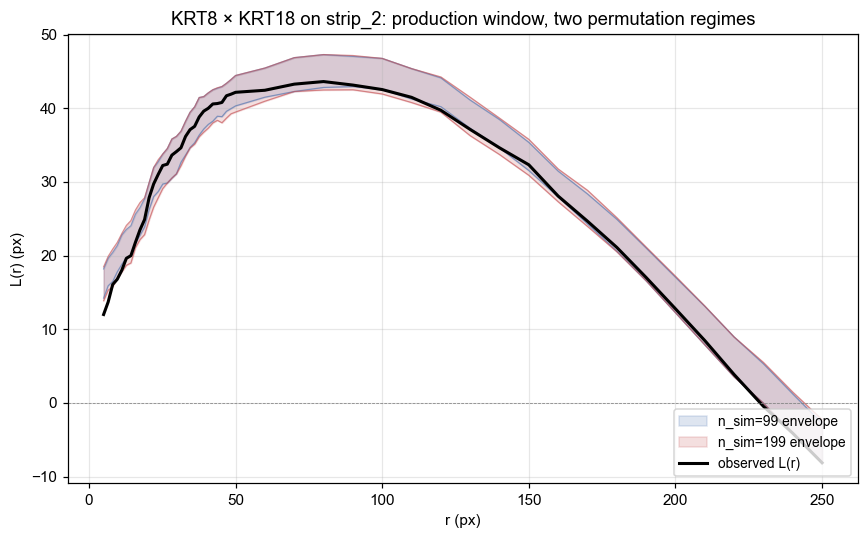

Saved → ..\results\figures\13_positive_anchor_retest.png


In [7]:
PALETTE = {99: '#4C72B0', 199: '#C44E52'}

fig, ax = plt.subplots(figsize=(8, 5))

for n_sim, env in envelopes.items():
    color = PALETTE[n_sim]
    ax.fill_between(
        r_vals, env['l_lo'], env['l_hi'],
        color=color, alpha=0.18,
        label=f'n_sim={n_sim} envelope',
    )
    ax.plot(r_vals, env['l_hi'], color=color, lw=0.8, alpha=0.6)
    ax.plot(r_vals, env['l_lo'], color=color, lw=0.8, alpha=0.6)

ax.plot(r_vals, l_obs, color='black', lw=2.0, label='observed L(r)')
ax.axhline(0, color='grey', lw=0.5, ls='--')

# Mark radii where l_obs exceeds each envelope
y_obs_max = l_obs.max()
for i, n_sim in enumerate(N_SIM_VALUES):
    above = l_obs > envelopes[n_sim]['l_hi']
    if above.any():
        y = y_obs_max * (1.08 + 0.05 * i)
        ax.scatter(r_vals[above], np.full(above.sum(), y),
                   color=PALETTE[n_sim], marker='|', s=80,
                   label=f'exceeds n_sim={n_sim} envelope')

ax.set_xlabel('r (px)')
ax.set_ylabel('L(r) (px)')
ax.set_title(f'{GENE_A} × {GENE_B} on {STRIP}: production window, '
             f'two permutation regimes')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()

out_path = FIGS / '13_positive_anchor_retest.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## 6. Verdict

Read the result from section 4:
- Both n_sim pass: the production envelope is fine; the near-empty network is a panel
  effect, not a power problem. Move to the extended panel and an effect-size network.
- Only n_sim=99 passes: the production envelope was over-strict; re-run the screen at
  n_sim=99.
- Neither passes: the window or edge correction has lost sensitivity relative to nb04;
  investigate nb09c (window comparison) and nb09 (edge-correction bias) first.

## 7. Negative-control sanity check: MALAT1 x KRT18

For KRT8 x KRT18 the observed L(r) sits inside both envelopes with a dome shape that the
envelope also shows: the dome is the tissue itself (all transcripts concentrate in
epithelial regions, so any two look co-clustered at the tissue scale), and the
permutation null correctly tracks it. The worry is whether the tight concave hull has
flattened the test so nothing can exceed the envelope.

MALAT1 x KRT18 tests that cheaply. MALAT1 (a broadly expressed nuclear lncRNA) and KRT18
(tissue-confined epithelial cytokeratin) have genuinely different spatial supports, so
the test should place L(r) clearly below the envelope midline (negative SES),
distinguishable from KRT8 x KRT18's near-zero SES. Separation means the test
discriminates and we can rank by effect size; no separation means the null is too
aggressive and needs revising.

In [8]:
GENE_NEG = 'MALAT1'

coords_neg = get_coords(strip_df, GENE_NEG)
print(f'{GENE_NEG}: {len(coords_neg):,} transcripts on {STRIP}')

# Reuse the same window + r_vals as the positive control.
# max_n + seed must match between bivariate_k (observed) and compute_envelope
# so both see the same subsampled subset of MALAT1 transcripts.
k_obs_neg = bivariate_k(
    coords_neg, coords_b, r_vals, window,
    resolution=RESOLUTION,
    max_n=MAX_N, seed=SEED,
)
l_obs_neg = k_to_l(k_obs_neg, r_vals)

# One envelope is enough - Section 3 showed n_sim=99 and n_sim=199 are equivalent
print(f'  computing envelope at n_sim=99 (max_n={MAX_N}) ...', end=' ', flush=True)
l_lo_neg, l_hi_neg = compute_envelope(
    coords_neg, coords_b, r_vals, window,
    n_sim=99, seed=SEED, resolution=RESOLUTION,
    max_n=MAX_N,
)
print('done')

# Peak signed SES (same formula as nb12) for both pairs, for direct comparison
def peak_signed_ses(l_obs_arr, l_lo_arr, l_hi_arr):
    mid  = (l_hi_arr + l_lo_arr) / 2
    half = (l_hi_arr - l_lo_arr) / 2
    ses  = np.where(half > 1e-9, (l_obs_arr - mid) / half, 0.0)
    return float(ses[int(np.argmax(np.abs(ses)))])

ses_pos = peak_signed_ses(l_obs,     envelopes[99]['l_lo'], envelopes[99]['l_hi'])
ses_neg = peak_signed_ses(l_obs_neg, l_lo_neg,              l_hi_neg)

print()
print('Peak signed SES (units: envelope half-widths from midline):')
print(f'  KRT8   × KRT18  (expected co-localised): {ses_pos:+.2f}')
print(f'  MALAT1 × KRT18  (expected anti-correl.): {ses_neg:+.2f}')
print()
print(f'Separation: {ses_pos - ses_neg:+.2f}')
print('Test discriminates if the negative-control SES is meaningfully lower '
      'than the positive-control SES.')

MALAT1: 16,808 transcripts on strip_2


  computing envelope at n_sim=99 (max_n=3000) ... 

done

Peak signed SES (units: envelope half-widths from midline):
  KRT8   × KRT18  (expected co-localised): -2.18
  MALAT1 × KRT18  (expected anti-correl.): -4.85

Separation: +2.67
Test discriminates if the negative-control SES is meaningfully lower than the positive-control SES.


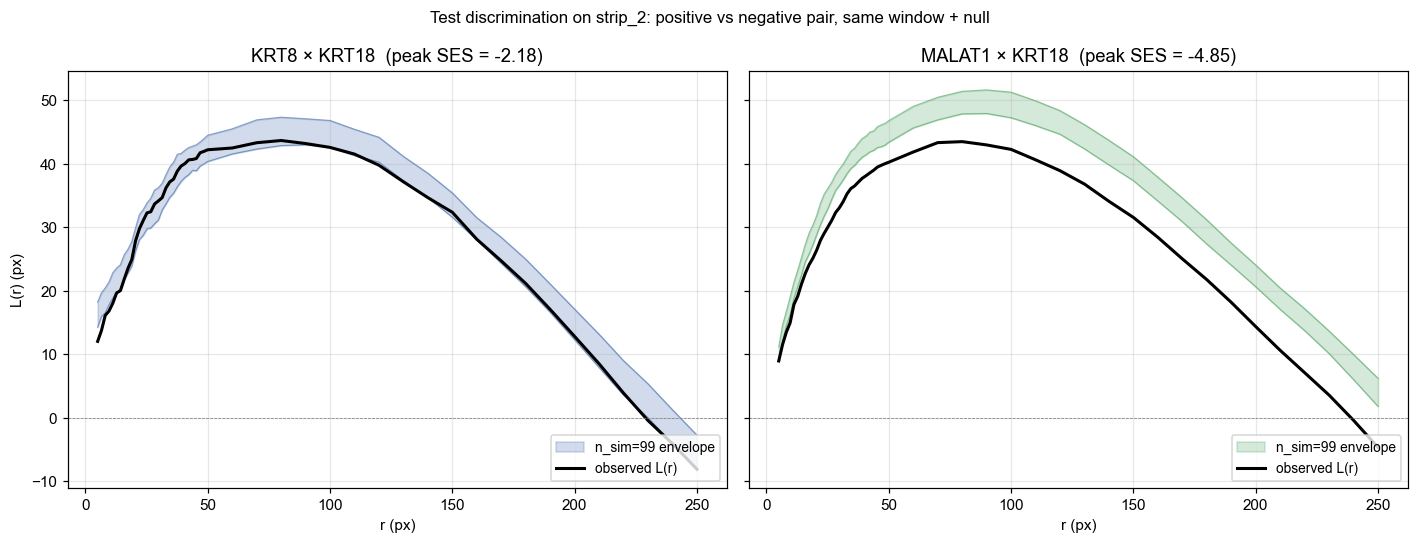

Saved → ..\results\figures\13_pos_vs_neg_sanity.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Left: KRT8 × KRT18 (positive control)
ax1.fill_between(r_vals, envelopes[99]['l_lo'], envelopes[99]['l_hi'],
                 color='#4C72B0', alpha=0.25, label='n_sim=99 envelope')
ax1.plot(r_vals, envelopes[99]['l_hi'], color='#4C72B0', lw=0.8, alpha=0.6)
ax1.plot(r_vals, envelopes[99]['l_lo'], color='#4C72B0', lw=0.8, alpha=0.6)
ax1.plot(r_vals, l_obs, color='black', lw=2.0, label='observed L(r)')
ax1.axhline(0, color='grey', lw=0.5, ls='--')
ax1.set_xlabel('r (px)')
ax1.set_ylabel('L(r) (px)')
ax1.set_title(f'KRT8 × KRT18  (peak SES = {ses_pos:+.2f})')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)

# Right: MALAT1 × KRT18 (negative control)
ax2.fill_between(r_vals, l_lo_neg, l_hi_neg,
                 color='#55A868', alpha=0.25, label='n_sim=99 envelope')
ax2.plot(r_vals, l_hi_neg, color='#55A868', lw=0.8, alpha=0.6)
ax2.plot(r_vals, l_lo_neg, color='#55A868', lw=0.8, alpha=0.6)
ax2.plot(r_vals, l_obs_neg, color='black', lw=2.0, label='observed L(r)')
ax2.axhline(0, color='grey', lw=0.5, ls='--')
ax2.set_xlabel('r (px)')
ax2.set_title(f'MALAT1 × KRT18  (peak SES = {ses_neg:+.2f})')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle(f'Test discrimination on {STRIP}: positive vs negative pair, '
             f'same window + null',
             fontsize=11)
plt.tight_layout()

out_path = FIGS / '13_pos_vs_neg_sanity.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

### What to look for

- Clean separation (negative SES <= -1): the test discriminates on the tight hull, so
  KRT8 x KRT18's near-zero SES is a real "no excess co-clustering" signal. Build the
  network on top-N pairs ranked by SES.
- Moderate separation (SES -0.5 to -1): effect-size ranking still works; a global
  rank-envelope test pooling across radii may recover more.
- No separation (SES near zero or positive): tissue inhomogeneity dominates every pair.
  Reconsider the null, e.g. an inhomogeneous K-function (Kinhom) or a restricted
  permutation pool among epithelial markers.

In [10]:
# Pool v1 + v2, attach pre-registered group labels, compute peak SES + r_at_peak per row
import sys
from pathlib import Path
import numpy as np
import pandas as pd

# Path resolution - handle "run from notebooks/" or "run from repo root"
REPO = Path("..") if Path("../results").is_dir() else Path(".")
RESULTS = REPO / "results"
SCRIPTS = REPO / "scripts"

# Import the canonical pair-group mapping from the manifest builder
sys.path.insert(0, str(SCRIPTS.resolve()))
from build_v2_manifest import EXTENDED_PAIRS                      # noqa: E402
V2_PAIR_GROUPS = {frozenset([L, R]): G for L, R, G in EXTENDED_PAIRS}

# Load both panels
v1 = pd.read_parquet(RESULTS / "lr_panel_results.parquet")
v2 = pd.read_parquet(RESULTS / "lr_panel_results_v2.parquet")
v1["source"] = "v1_cellchatdb"
v2["source"] = "v2_extended"

# Pool
df = pd.concat([v1, v2], ignore_index=True)

def assign_group(row):
    if row["source"] == "v1_cellchatdb":
        return "G0_cellchatdb"
    return V2_PAIR_GROUPS.get(frozenset([row["ligand"], row["receptor"]]), "G_unknown")

df["group"] = df.apply(assign_group, axis=1)

# Compute per-row peak SES (envelope half-widths) and the radius index where it peaks
def peak_ses_and_idx(row):
    obs  = np.asarray(row["l_obs"])
    lo   = np.asarray(row["l_lo"])
    hi   = np.asarray(row["l_hi"])
    mid  = (lo + hi) / 2.0
    half = np.maximum((hi - lo) / 2.0, 1e-9)
    ses_curve = (obs - mid) / half
    idx = int(np.argmax(ses_curve))
    return pd.Series({"peak_ses": float(ses_curve[idx]), "r_at_peak_idx": idx})

df = pd.concat([df, df.apply(peak_ses_and_idx, axis=1)], axis=1)

# Map index → r in px (v1 and v2 share r_vals; verified by aggregate scripts)
r_vals = np.load(RESULTS / "lr_panel_results.parquet.r_vals.npy")
df["r_at_peak_px"] = r_vals[df["r_at_peak_idx"].astype(int).values]

# Sanity report
print(f"Pooled rows: {len(df)}  (v1 = {len(v1)}, v2 = {len(v2)})\n")
print("Group counts:")
print(df["group"].value_counts().to_string())
print("\nGroup peak-SES summary:")
print(df.groupby("group")["peak_ses"].agg(["mean", "std", "min", "max", "count"]).round(3).to_string())

Pooled rows: 614  (v1 = 438, v2 = 176)

Group counts:
group
G0_cellchatdb         438
G7_infection           41
G4_immune_celltype     30
G1_cytokeratin         30
G8_paracrine           26
G5_stromal             22
G6_negative_anchor     21
G3_epi_niche            6

Group peak-SES summary:
                     mean    std    min    max  count
group                                                
G0_cellchatdb       0.274  0.388 -1.349  1.391    438
G1_cytokeratin     -0.194  0.672 -2.155  0.694     30
G3_epi_niche       -1.984  1.275 -4.103 -0.826      6
G4_immune_celltype  0.298  0.358 -0.755  0.961     30
G5_stromal          0.313  0.426 -0.570  1.091     22
G6_negative_anchor -0.158  0.905 -2.689  0.885     21
G7_infection        0.352  0.428 -0.884  1.140     41
G8_paracrine        0.402  0.468 -0.556  1.157     26


C:\Users\Harry\AppData\Local\Temp\ipykernel_21408\3851163497.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Harry\AppData\Local\Temp\ipykernel_21408\3851163497.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\Harry\AppData\Local\Temp\ipykernel_21408\3851163497.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([nice_labels[g] for g in group_order])


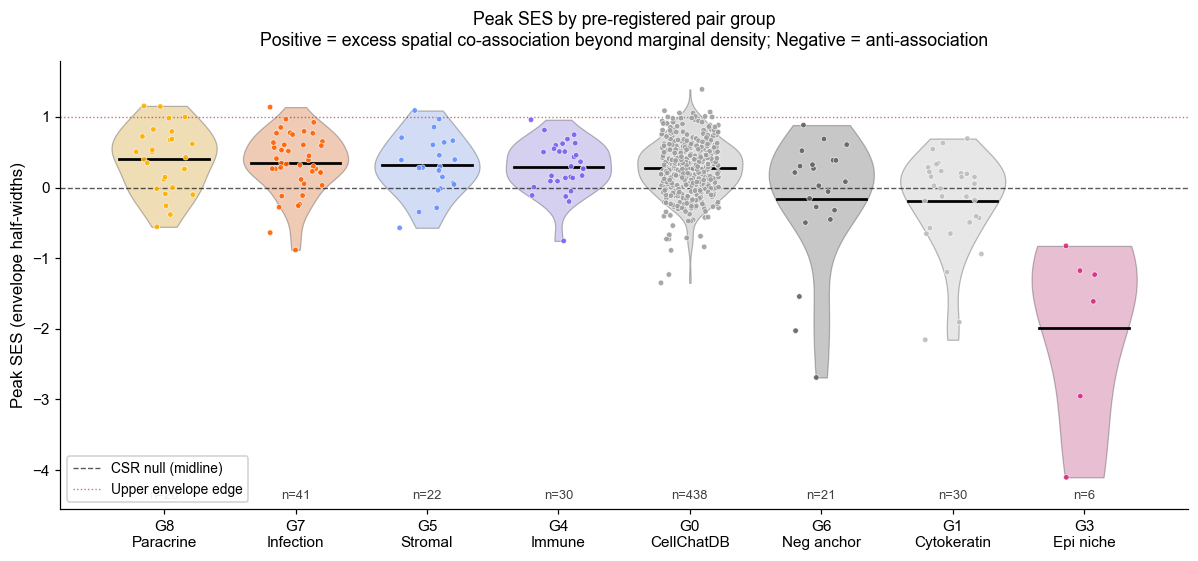

Saved: ..\results\figures\13_C_group_ses_distribution.png


In [11]:
# Fig D - Group-wise SES distribution (poster panel)
import matplotlib.pyplot as plt
import seaborn as sns

# Order groups by mean SES descending - left = most positive, right = most negative
group_order = (
    df.groupby("group")["peak_ses"].mean().sort_values(ascending=False).index.tolist()
)

# IBM-accessible palette (colour-blind safe) plus greys for the null-behaviour groups
palette = {
    "G8_paracrine":       "#FFB000",  # amber
    "G7_infection":       "#FE6100",  # red-orange
    "G5_stromal":         "#648FFF",  # blue
    "G4_immune_celltype": "#785EF0",  # purple
    "G0_cellchatdb":      "#9E9E9E",  # grey
    "G6_negative_anchor": "#616161",  # darker grey
    "G1_cytokeratin":     "#BDBDBD",  # light grey
    "G3_epi_niche":       "#DC267F",  # magenta - anti-association pole
}

nice_labels = {
    "G0_cellchatdb":      "G0\nCellChatDB",
    "G1_cytokeratin":     "G1\nCytokeratin",
    "G3_epi_niche":       "G3\nEpi niche",
    "G4_immune_celltype": "G4\nImmune",
    "G5_stromal":         "G5\nStromal",
    "G6_negative_anchor": "G6\nNeg anchor",
    "G7_infection":       "G7\nInfection",
    "G8_paracrine":       "G8\nParacrine",
}

fig, ax = plt.subplots(figsize=(11, 5.2))

# Violin for shape, stripplot for individual points
sns.violinplot(
    data=df, x="group", y="peak_ses",
    order=group_order, palette=palette,
    inner=None, cut=0, linewidth=0.8, ax=ax, saturation=0.65,
)
for v in ax.collections:                       # softer fill
    v.set_alpha(0.35)
sns.stripplot(
    data=df, x="group", y="peak_ses",
    order=group_order, palette=palette,
    size=3.6, jitter=0.22, alpha=0.9, ax=ax,
    edgecolor="white", linewidth=0.4,
)

# Reference lines
ax.axhline(0,  color="black",     ls="--", lw=0.9, alpha=0.65, label="CSR null (midline)")
ax.axhline(+1, color="firebrick", ls=":",  lw=0.9, alpha=0.65, label="Upper envelope edge")

# Mean bars
for i, g in enumerate(group_order):
    m = df.loc[df["group"] == g, "peak_ses"].mean()
    ax.plot([i - 0.34, i + 0.34], [m, m], color="black", lw=1.8)

# n= annotations along the bottom
ymin = df["peak_ses"].min() - 0.35
for i, g in enumerate(group_order):
    n = int((df["group"] == g).sum())
    ax.text(i, ymin, f"n={n}", ha="center", va="bottom",
            fontsize=8.5, alpha=0.75, color="black")

ax.set_xticklabels([nice_labels[g] for g in group_order])
ax.set_xlabel("")
ax.set_ylabel("Peak SES (envelope half-widths)", fontsize=11)
ax.set_title("Peak SES by pre-registered pair group\n"
             "Positive = excess spatial co-association beyond marginal density; "
             "Negative = anti-association",
             fontsize=11.5, pad=10)
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
ax.set_ylim(ymin - 0.1, df["peak_ses"].max() + 0.4)

sns.despine()
plt.tight_layout()

out = REPO / "results" / "figures" / "13_C_group_ses_distribution.png"
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

C:\Users\Harry\AppData\Local\Temp\ipykernel_21408\4220984128.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.91, 0.96])


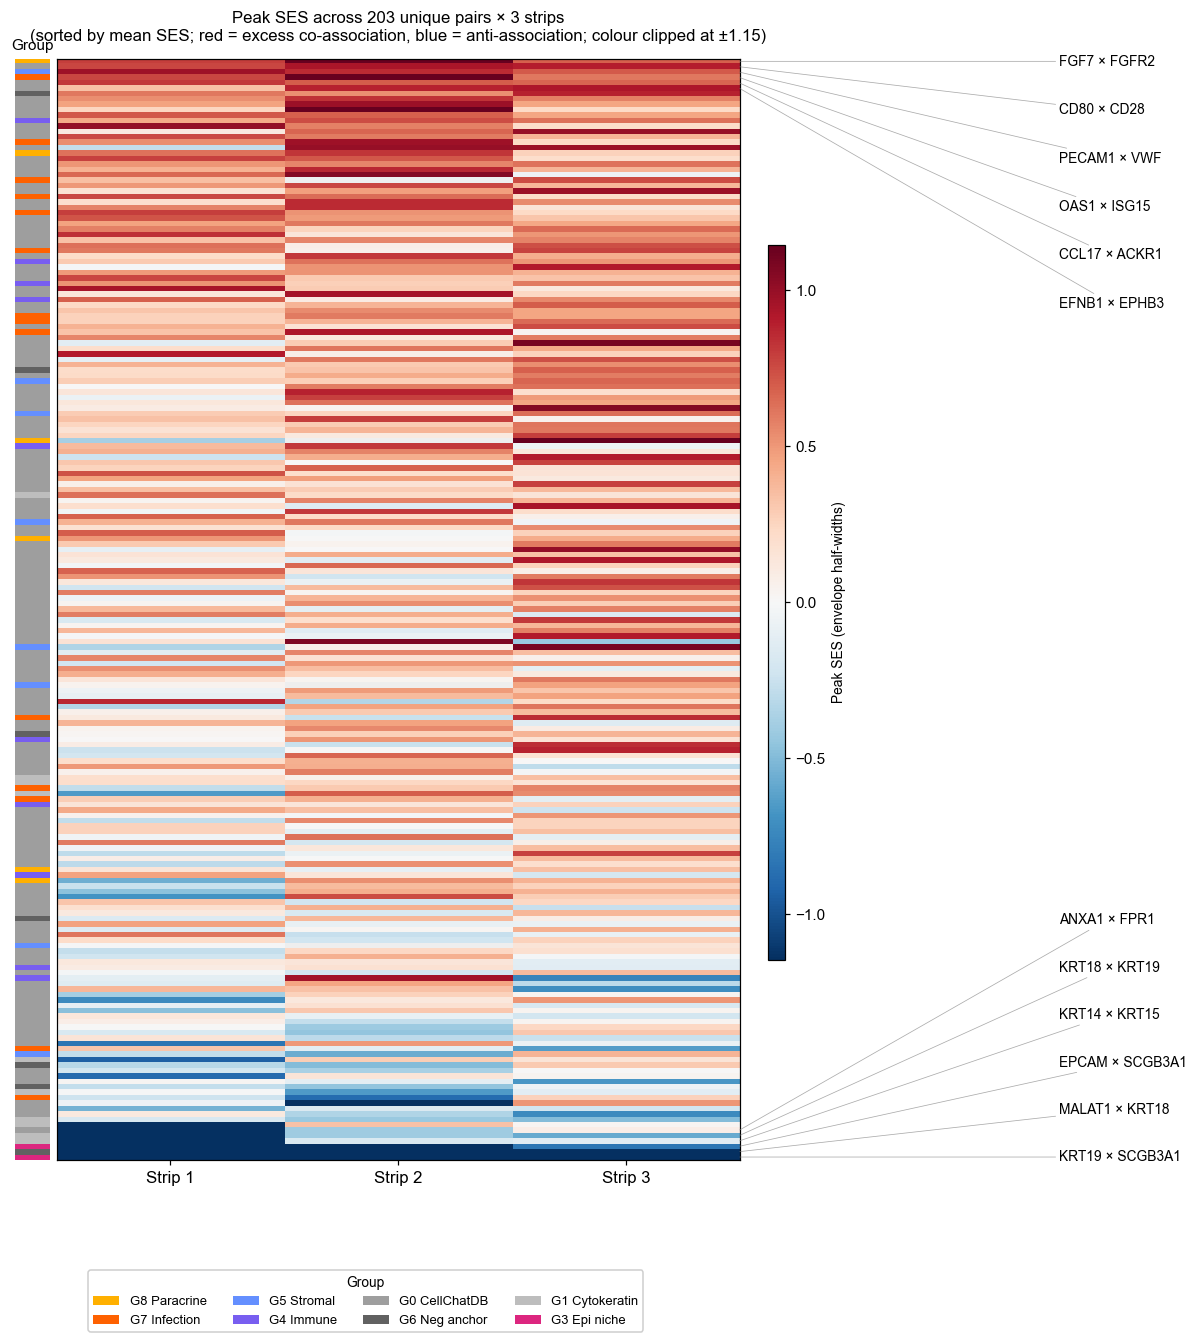

Saved: ..\results\figures\13_D_ses_heatmap.png  (203 pairs)


In [12]:
# Fig D - SES heatmap, revised: tighter palette, right-side labels with leader lines
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

# Pair-level pivot (unchanged from before)
pair_df  = df.assign(pair=df["ligand"] + " × " + df["receptor"])
heat     = pair_df.pivot_table(index="pair", columns="strip", values="peak_ses")
pair_mean   = pair_df.groupby("pair")["peak_ses"].mean()
pair_group  = pair_df.groupby("pair")["group"].first()

order            = pair_mean.sort_values(ascending=False).index
heat             = heat.loc[order]
groups_ordered   = pair_group.loc[order]
N                = len(order)

# Tighter colour scale - clip at 97.5th percentile of |SES| so the mid-range isn't washed by the G3 tail
vmax = float(np.nanpercentile(np.abs(heat.values), 97.5))

fig, axes = plt.subplots(
    1, 2, figsize=(8.5, 13),
    gridspec_kw={"width_ratios": [0.05, 1.0], "wspace": 0.02}
)
ax_g, ax_h = axes

# Group colour strip
group_rgb = np.array([to_rgb(palette.get(g, "#cccccc")) for g in groups_ordered])[:, np.newaxis, :]
ax_g.imshow(group_rgb, aspect="auto", interpolation="nearest")
ax_g.set_xticks([]); ax_g.set_yticks([])
ax_g.set_title("Group", fontsize=10, pad=6)
for s in ax_g.spines.values():
    s.set_visible(False)

# Main heatmap
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#eeeeee")
heat_arr = np.ma.masked_invalid(heat.values)
im = ax_h.imshow(heat_arr, aspect="auto", cmap=cmap,
                 vmin=-vmax, vmax=+vmax, interpolation="nearest")
ax_h.set_yticks([])
ax_h.set_xticks(range(len(heat.columns)))
ax_h.set_xticklabels([s.replace("strip_", "Strip ") for s in heat.columns], fontsize=11)

# Pair labels on the RIGHT with leader lines, vertically spread so they don't collide
N_LABEL  = 6
top_rows = list(range(N_LABEL))
bot_rows = list(range(N - N_LABEL, N))

# Spread top labels evenly through the first ~22 % of the heatmap height,
# and bottom labels through the last ~22 %; leader lines bridge to actual row positions
top_slots = np.linspace(0,             N * 0.22, N_LABEL)
bot_slots = np.linspace(N * 0.78,      N - 1,    N_LABEL)
label_x   = len(heat.columns) - 0.5

for slot_y, row_i in zip(top_slots, top_rows):
    ax_h.annotate(order[row_i],
                  xy=(label_x, row_i),
                  xytext=(label_x + 1.4, slot_y),
                  fontsize=9, va="center", ha="left",
                  arrowprops=dict(arrowstyle="-", color="#888", lw=0.5, alpha=0.7,
                                  shrinkA=0, shrinkB=0),
                  annotation_clip=False)
for slot_y, row_i in zip(bot_slots, bot_rows):
    ax_h.annotate(order[row_i],
                  xy=(label_x, row_i),
                  xytext=(label_x + 1.4, slot_y),
                  fontsize=9, va="center", ha="left",
                  arrowprops=dict(arrowstyle="-", color="#888", lw=0.5, alpha=0.7,
                                  shrinkA=0, shrinkB=0),
                  annotation_clip=False)

ax_h.set_title(
    f"Peak SES across {N} unique pairs × {len(heat.columns)} strips\n"
    f"(sorted by mean SES; red = excess co-association, blue = anti-association; colour clipped at ±{vmax:.2f})",
    fontsize=11, pad=12
)

# Colour bar - separate axes to the right of the labels
cbar_ax = fig.add_axes([0.93, 0.25, 0.018, 0.5])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Peak SES (envelope half-widths)", fontsize=9)

# Group legend - horizontal, below the figure (won't collide)
present_groups = [g for g in group_order if g in set(groups_ordered)]
legend_handles = [Patch(facecolor=palette[g], label=nice_labels[g].replace("\n", " "))
                  for g in present_groups]
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.015),
           fontsize=8.5, ncol=4, framealpha=0.95, title="Group", title_fontsize=9)

plt.tight_layout(rect=[0, 0.03, 0.91, 0.96])

out = REPO / "results" / "figures" / "13_D_ses_heatmap.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}  ({N} pairs)")

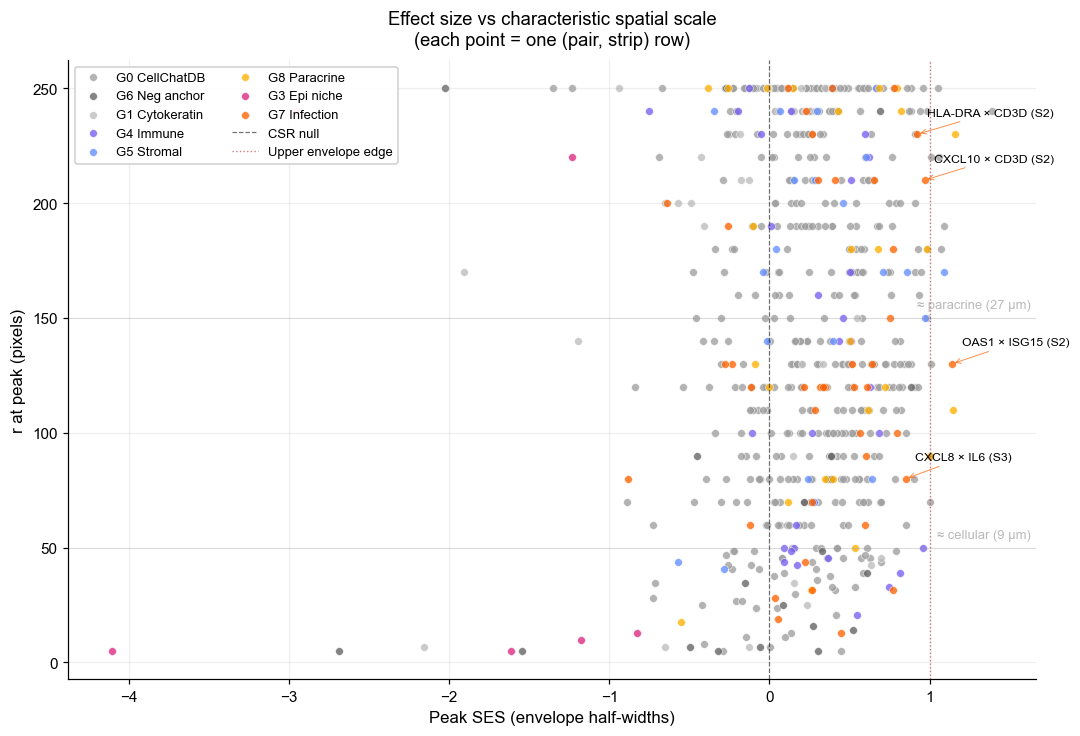

Saved: ..\results\figures\13_E_volcano.png


In [13]:
# Fig E - Volcano-style scatter: peak SES vs r at peak, coloured by group
fig, ax = plt.subplots(figsize=(10, 6.8))

# Draw groups in an order that puts focal/interesting ones on top of the diffuse cloud
plot_order = ["G0_cellchatdb", "G6_negative_anchor", "G1_cytokeratin",
              "G4_immune_celltype", "G5_stromal", "G8_paracrine",
              "G3_epi_niche", "G7_infection"]

for g in plot_order:
    sub = df[df["group"] == g]
    if len(sub) == 0:
        continue
    ax.scatter(sub["peak_ses"], sub["r_at_peak_px"],
               c=palette[g], s=26, alpha=0.78,
               edgecolor="white", linewidth=0.4,
               label=nice_labels[g].replace("\n", " "))

# Reference lines (SES = 0 = CSR null midline; SES = +1 = upper envelope edge)
ax.axvline(0,  color="black",     ls="--", lw=0.8, alpha=0.55, label="CSR null")
ax.axvline(+1, color="firebrick", ls=":",  lw=0.9, alpha=0.6,  label="Upper envelope edge")

# Spatial-scale guide lines on the y-axis
# scale reported in pixels (CosMx nominal ~0.12 um/px, uncalibrated)
xmin, xmax = ax.get_xlim()
for y_px, lbl in [(50, "≈ cellular (9 µm)"), (150, "≈ paracrine (27 µm)")]:
    ax.axhline(y_px, color="grey", ls="-", lw=0.4, alpha=0.3)
    ax.text(xmax * 0.98, y_px + 3, lbl, ha="right", va="bottom",
            fontsize=8.5, alpha=0.55, color="grey")

# Highlight the top G7 infection pairs by name (the biological headline)
g7_top = df[df["group"] == "G7_infection"].nlargest(4, "peak_ses")
for _, row in g7_top.iterrows():
    lbl = f"{row['ligand']} × {row['receptor']} ({row['strip'].replace('strip_', 'S')})"
    ax.annotate(lbl,
                xy=(row["peak_ses"], row["r_at_peak_px"]),
                xytext=(row["peak_ses"] + 0.06, row["r_at_peak_px"] + 8),
                fontsize=8, fontweight="medium",
                arrowprops=dict(arrowstyle="->", color="#FE6100",
                                lw=0.6, alpha=0.75))

ax.set_xlabel("Peak SES (envelope half-widths)", fontsize=11)
ax.set_ylabel("r at peak (pixels)", fontsize=11)
ax.set_title("Effect size vs characteristic spatial scale\n"
             "(each point = one (pair, strip) row)",
             fontsize=12, pad=10)
ax.legend(loc="upper left", fontsize=8.5, framealpha=0.92, ncol=2)
ax.grid(alpha=0.2)
sns.despine()

plt.tight_layout()
out = REPO / "results" / "figures" / "13_E_volcano.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

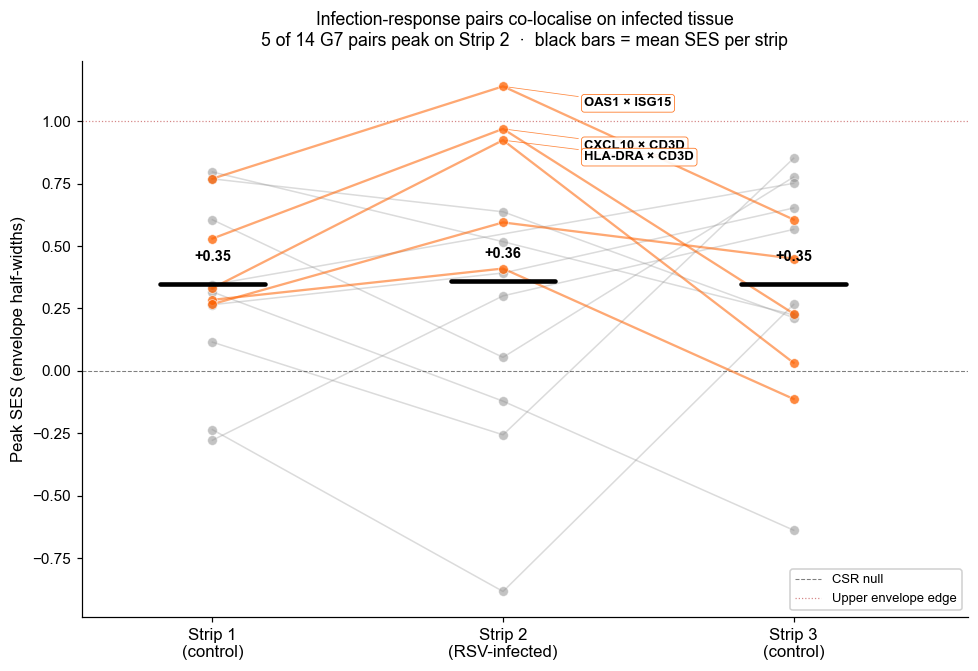

Saved: ..\results\figures\13_F_infection_signature.png
5 of 14 G7 pairs peak on Strip 2 (36%)


In [14]:
# Fig F - Infection-response (G7) pairs across tissue strips: the biological headline
g7       = df[df["group"] == "G7_infection"].copy()
g7_pivot = g7.pivot_table(index=["ligand", "receptor"], columns="strip", values="peak_ses")

fig, ax = plt.subplots(figsize=(9, 6.2))

n_total = 0
n_strip2_max = 0

# Per-pair paired strip plot - line connects each pair's SES across the 3 strips
for (lig, rec), row in g7_pivot.iterrows():
    y = [row.get("strip_1"), row.get("strip_2"), row.get("strip_3")]
    valid = [(i, v) for i, v in enumerate(y) if pd.notna(v)]
    if len(valid) < 2:
        continue
    n_total += 1

    x_v = [v[0] + 1 for v in valid]
    y_v = [v[1] for v in valid]

    s1, s2, s3 = y
    strip2_highest = (pd.notna(s2)
                     and (pd.isna(s1) or s2 > s1)
                     and (pd.isna(s3) or s2 > s3))

    if strip2_highest:
        n_strip2_max += 1
        color, alpha, lw, z = "#FE6100", 0.55, 1.5, 3
    else:
        color, alpha, lw, z = "#888888", 0.30, 1.0, 1

    ax.plot(x_v, y_v, color=color, alpha=alpha, lw=lw, zorder=z)
    for x, ypt in zip(x_v, y_v):
        ax.scatter(x, ypt, color=color, s=40, alpha=alpha + 0.2,
                   edgecolor="white", linewidth=0.5, zorder=z + 0.5)

# Mean SES per strip (heavy black bars + numeric label)
for strip_n in [1, 2, 3]:
    m = g7[g7["strip"] == f"strip_{strip_n}"]["peak_ses"].mean()
    ax.plot([strip_n - 0.18, strip_n + 0.18], [m, m],
            color="black", lw=3, solid_capstyle="round", zorder=10)
    ax.text(strip_n, m + 0.08, f"{m:+.2f}", ha="center", va="bottom",
            fontsize=9.5, fontweight="bold", zorder=11)

# Reference lines
ax.axhline(0,  color="black",     ls="--", lw=0.7, alpha=0.5, label="CSR null")
ax.axhline(+1, color="firebrick", ls=":",  lw=0.8, alpha=0.55, label="Upper envelope edge")

# Annotate the four top G7 pairs at strip_2
top4 = [("OAS1", "ISG15"), ("CXCL10", "CD3D"), ("HLA-DRA", "CD3D"), ("CD68", "CD14")]
for lig, rec in top4:
    if (lig, rec) in g7_pivot.index:
        ses2 = g7_pivot.loc[(lig, rec), "strip_2"]
        if pd.notna(ses2):
            ax.annotate(f"{lig} × {rec}",
                        xy=(2, ses2),
                        xytext=(2.28, ses2 - 0.08),
                        fontsize=8.5, fontweight="semibold",
                        arrowprops=dict(arrowstyle="-", color="#FE6100", lw=0.5, alpha=0.75),
                        bbox=dict(boxstyle="round,pad=0.22", fc="white",
                                  ec="#FE6100", lw=0.5, alpha=0.9))

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["Strip 1\n(control)", "Strip 2\n(RSV-infected)", "Strip 3\n(control)"],
                   fontsize=11)
ax.set_xlim(0.55, 3.6)
ax.set_ylabel("Peak SES (envelope half-widths)", fontsize=11)
ax.set_title(f"Infection-response pairs co-localise on infected tissue\n"
             f"{n_strip2_max} of {n_total} G7 pairs peak on Strip 2  ·  black bars = mean SES per strip",
             fontsize=11.5, pad=10)
ax.legend(loc="lower right", fontsize=8.5, framealpha=0.92)
sns.despine()
plt.tight_layout()

out = REPO / "results" / "figures" / "13_F_infection_signature.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")
print(f"{n_strip2_max} of {n_total} G7 pairs peak on Strip 2 "
      f"({n_strip2_max/max(n_total,1):.0%})")

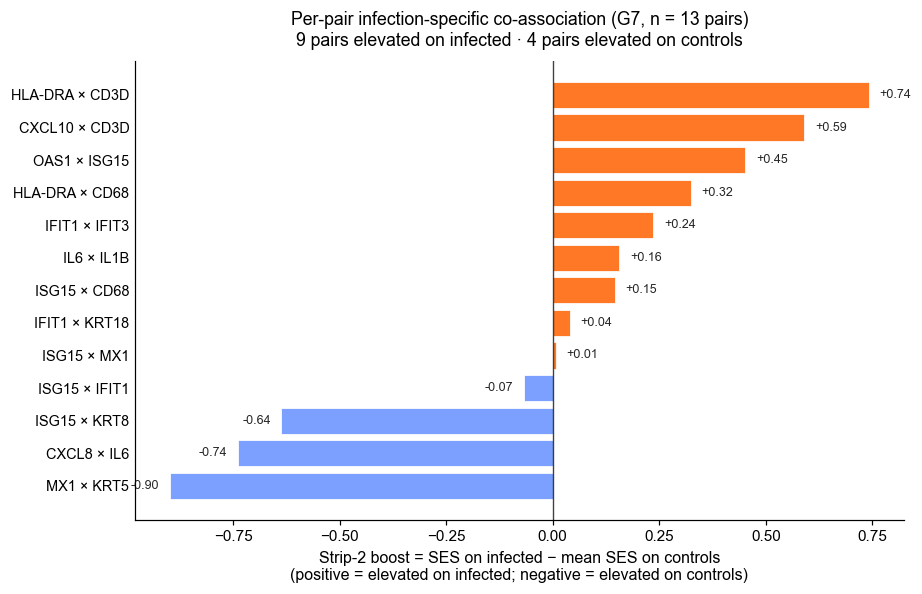

Saved: ..\results\figures\13_F_infection_signature.png

Strip-2 boost summary for G7 (n=13):
strip             strip_1  strip_2  strip_3  boost
ligand  receptor                                  
MX1     KRT5       -0.235   -0.884    0.266 -0.899
CXCL8   IL6         0.115   -0.256    0.851 -0.739
ISG15   KRT8        0.605    0.054    0.776 -0.637
        IFIT1       0.265    0.392    0.652 -0.067
        MX1         0.797    0.517    0.224  0.007
IFIT1   KRT18       0.316   -0.121   -0.638  0.040
ISG15   CD68        0.769    0.637    0.213  0.146
IL6     IL1B       -0.278    0.300    0.566  0.156
IFIT1   IFIT3       0.267    0.594    0.449  0.236
HLA-DRA CD68        0.284    0.410   -0.113  0.324
OAS1    ISG15       0.770    1.140    0.606  0.452
CXCL10  CD3D        0.530    0.969    0.229  0.590
HLA-DRA CD3D        0.331    0.924    0.032  0.742


In [15]:
# Fig F (revised) - Per-pair Strip-2 boost: SES on infected minus mean SES on controls
g7        = df[df["group"] == "G7_infection"].copy()
g7_pivot  = g7.pivot_table(index=["ligand", "receptor"], columns="strip", values="peak_ses")

# Need all three strips to compute boost honestly
plotable  = g7_pivot.dropna(subset=["strip_1", "strip_2", "strip_3"]).copy()
plotable["boost"] = plotable["strip_2"] - plotable[["strip_1", "strip_3"]].mean(axis=1)
plotable = plotable.sort_values("boost", ascending=True)

n_total = len(plotable)
n_up    = int((plotable["boost"] > 0).sum())
n_down  = int((plotable["boost"] < 0).sum())

fig, ax = plt.subplots(figsize=(8.5, max(5.5, 0.36 * n_total)))

y_positions = np.arange(n_total)
boosts = plotable["boost"].values
colors = ["#FE6100" if b > 0 else "#648FFF" for b in boosts]
ax.barh(y_positions, boosts, color=colors, alpha=0.85,
        edgecolor="white", linewidth=0.6)
ax.axvline(0, color="black", lw=0.9, alpha=0.75)

# Pair name labels
pair_labels = [f"{lig} × {rec}" for lig, rec in plotable.index]
ax.set_yticks(y_positions)
ax.set_yticklabels(pair_labels, fontsize=9.5)

# Numeric boost value at the bar tip
for y, b in zip(y_positions, boosts):
    ax.text(b + (0.025 if b >= 0 else -0.025), y,
            f"{b:+.2f}",
            ha="left" if b >= 0 else "right", va="center",
            fontsize=8.2, alpha=0.85)

# Title carries the honest summary
ax.set_xlabel("Strip-2 boost = SES on infected − mean SES on controls\n"
              "(positive = elevated on infected; negative = elevated on controls)",
              fontsize=10.5)
ax.set_title(
    f"Per-pair infection-specific co-association (G7, n = {n_total} pairs)\n"
    f"{n_up} pairs elevated on infected · {n_down} pairs elevated on controls",
    fontsize=11.5, pad=10
)

# Soften the right/top spines but keep the zero line clean
sns.despine(left=False, bottom=False)
ax.tick_params(axis="y", which="both", length=0)
plt.tight_layout()

out = REPO / "results" / "figures" / "13_F_infection_signature.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")
print(f"\nStrip-2 boost summary for G7 (n={n_total}):")
print(plotable[["strip_1", "strip_2", "strip_3", "boost"]].round(3).to_string())

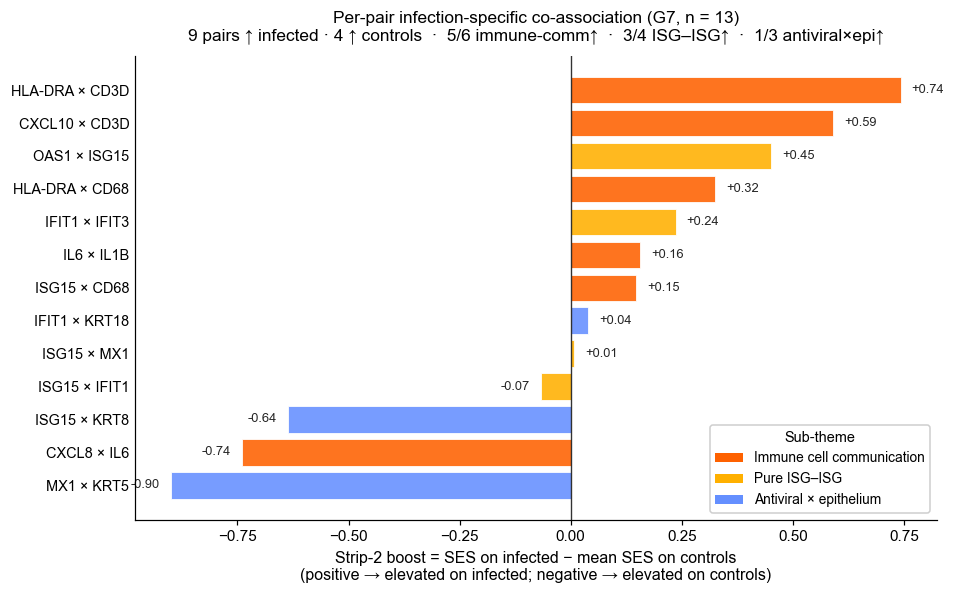

Saved: ..\results\figures\13_F_infection_signature.png

Mean boost by sub-theme:
                            mean    min    max  count
subtheme                                             
Antiviral × epithelium    -0.499 -0.899  0.040      3
Immune cell communication  0.203 -0.739  0.742      6
Pure ISG–ISG               0.157 -0.067  0.452      4

Positive vs negative count by sub-theme:
                           positive_count  total  neg_count
subtheme                                                   
Antiviral × epithelium                  1      3          2
Immune cell communication               5      6          1
Pure ISG–ISG                            3      4          1


In [16]:
# Fig F - Per-pair Strip-2 boost, sub-themed by biology; title built from the actual data so it can't drift
from matplotlib.patches import Patch

# --- Data prep ---
g7        = df[df["group"] == "G7_infection"].copy()
g7_pivot  = g7.pivot_table(index=["ligand", "receptor"], columns="strip", values="peak_ses")
plotable  = g7_pivot.dropna(subset=["strip_1", "strip_2", "strip_3"]).copy()
plotable["boost"] = plotable["strip_2"] - plotable[["strip_1", "strip_3"]].mean(axis=1)
plotable = plotable.sort_values("boost", ascending=True)

# --- Sub-theme classifier ---
IMMUNE_CELL_GENES = {"CD3D", "CD3E", "CD4", "CD8A", "CD8B", "CD68", "CD163",
                     "CD14", "CXCL10", "CXCL8", "HLA-DRA", "IL1B", "IL6", "TNF"}
ISG_GENES         = {"ISG15", "IFIT1", "IFIT3", "MX1", "OAS1"}
EPITHELIAL_GENES  = {"KRT5", "KRT8", "KRT14", "KRT18", "KRT19"}

def subtheme(lig, rec):
    g = {lig, rec}
    if g & EPITHELIAL_GENES and g & ISG_GENES:
        return "Antiviral × epithelium"
    if g.issubset(ISG_GENES):
        return "Pure ISG–ISG"
    if g & IMMUNE_CELL_GENES and not (g & EPITHELIAL_GENES):
        return "Immune cell communication"
    return "Other"

plotable["subtheme"] = [subtheme(l, r) for l, r in plotable.index]

theme_palette = {
    "Immune cell communication": "#FE6100",   # warm orange
    "Pure ISG–ISG":              "#FFB000",   # yellow
    "Antiviral × epithelium":    "#648FFF",   # cool blue
    "Other":                     "#9E9E9E",   # grey
}

# --- Data-driven counts for the title ---
n_total = len(plotable)
n_up    = int((plotable["boost"] > 0).sum())
n_down  = int((plotable["boost"] < 0).sum())

theme_counts = (
    plotable.assign(positive=plotable["boost"] > 0)
            .groupby("subtheme")["positive"]
            .agg(positive_count="sum", total="count")
)

def theme_chip(name, short):
    if name not in theme_counts.index:
        return None
    row = theme_counts.loc[name]
    return f"{int(row['positive_count'])}/{int(row['total'])} {short}↑"

chips = [c for c in [
    theme_chip("Immune cell communication", "immune-comm"),
    theme_chip("Pure ISG–ISG",              "ISG–ISG"),
    theme_chip("Antiviral × epithelium",    "antiviral×epi"),
    theme_chip("Other",                     "other"),
] if c]
chip_str = "  ·  ".join(chips)

# --- Figure ---
fig, ax = plt.subplots(figsize=(8.8, max(5.5, 0.4 * n_total)))
y_positions = np.arange(n_total)
colors = [theme_palette[t] for t in plotable["subtheme"]]
ax.barh(y_positions, plotable["boost"].values, color=colors, alpha=0.88,
        edgecolor="white", linewidth=0.6)
ax.axvline(0, color="black", lw=0.9, alpha=0.8)

pair_labels = [f"{lig} × {rec}" for lig, rec in plotable.index]
ax.set_yticks(y_positions)
ax.set_yticklabels(pair_labels, fontsize=9.5)

for y, b in zip(y_positions, plotable["boost"].values):
    ax.text(b + (0.025 if b >= 0 else -0.025), y, f"{b:+.2f}",
            ha="left" if b >= 0 else "right", va="center",
            fontsize=8.4, alpha=0.85)

# Legend by sub-theme (only present themes)
present_themes = [t for t in theme_palette if t in set(plotable["subtheme"])]
handles = [Patch(facecolor=theme_palette[t], label=t) for t in present_themes]
ax.legend(handles=handles, loc="lower right", fontsize=9, framealpha=0.95,
          title="Sub-theme", title_fontsize=9.5)

ax.set_xlabel("Strip-2 boost = SES on infected − mean SES on controls\n"
              "(positive → elevated on infected; negative → elevated on controls)",
              fontsize=10.5)
ax.set_title(
    f"Per-pair infection-specific co-association (G7, n = {n_total})\n"
    f"{n_up} pairs ↑ infected · {n_down} ↑ controls  ·  {chip_str}",
    fontsize=11.3, pad=10
)

sns.despine(left=False, bottom=False)
ax.tick_params(axis="y", which="both", length=0)
plt.tight_layout()

out = REPO / "results" / "figures" / "13_F_infection_signature.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

# Honest sub-theme stats - print after the figure so they're easy to read
print("\nMean boost by sub-theme:")
print(plotable.groupby("subtheme")["boost"].agg(["mean", "min", "max", "count"]).round(3))
print("\nPositive vs negative count by sub-theme:")
print(theme_counts.assign(neg_count=lambda d: d["total"] - d["positive_count"]).to_string())

## 8. Fig G: per-strip co-association network with Louvain communities

One undirected graph per strip from the top-50 (pair, strip) rows by peak SES (positive
co-association only): nodes = genes, edge weight = peak SES, Louvain communities read as
candidate spatial signalling modules recovered without segmentation.

Decisions: TOP_N_EDGES = 50 per strip; at this sparsity most edges are disjoint pairs, so
only genuine modules (Louvain communities of >= 3 genes) are coloured and isolated pairs
greyed. SEED=42 for Louvain and layout (repeat over >=5 seeds for a robust result). Peak
SES here is the max over r, the same ranking metric as the other figures, not the
signed-peak used for control discrimination in section 7.

C:\Users\Harry\AppData\Local\Temp\ipykernel_21408\42620657.py:61: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Harry\AppData\Local\Temp\ipykernel_21408\42620657.py:64: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig(out, dpi=300, bbox_inches="tight")


C:\Users\Harry\Desktop\NoSegs_Project\cosmx-pointpattern\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


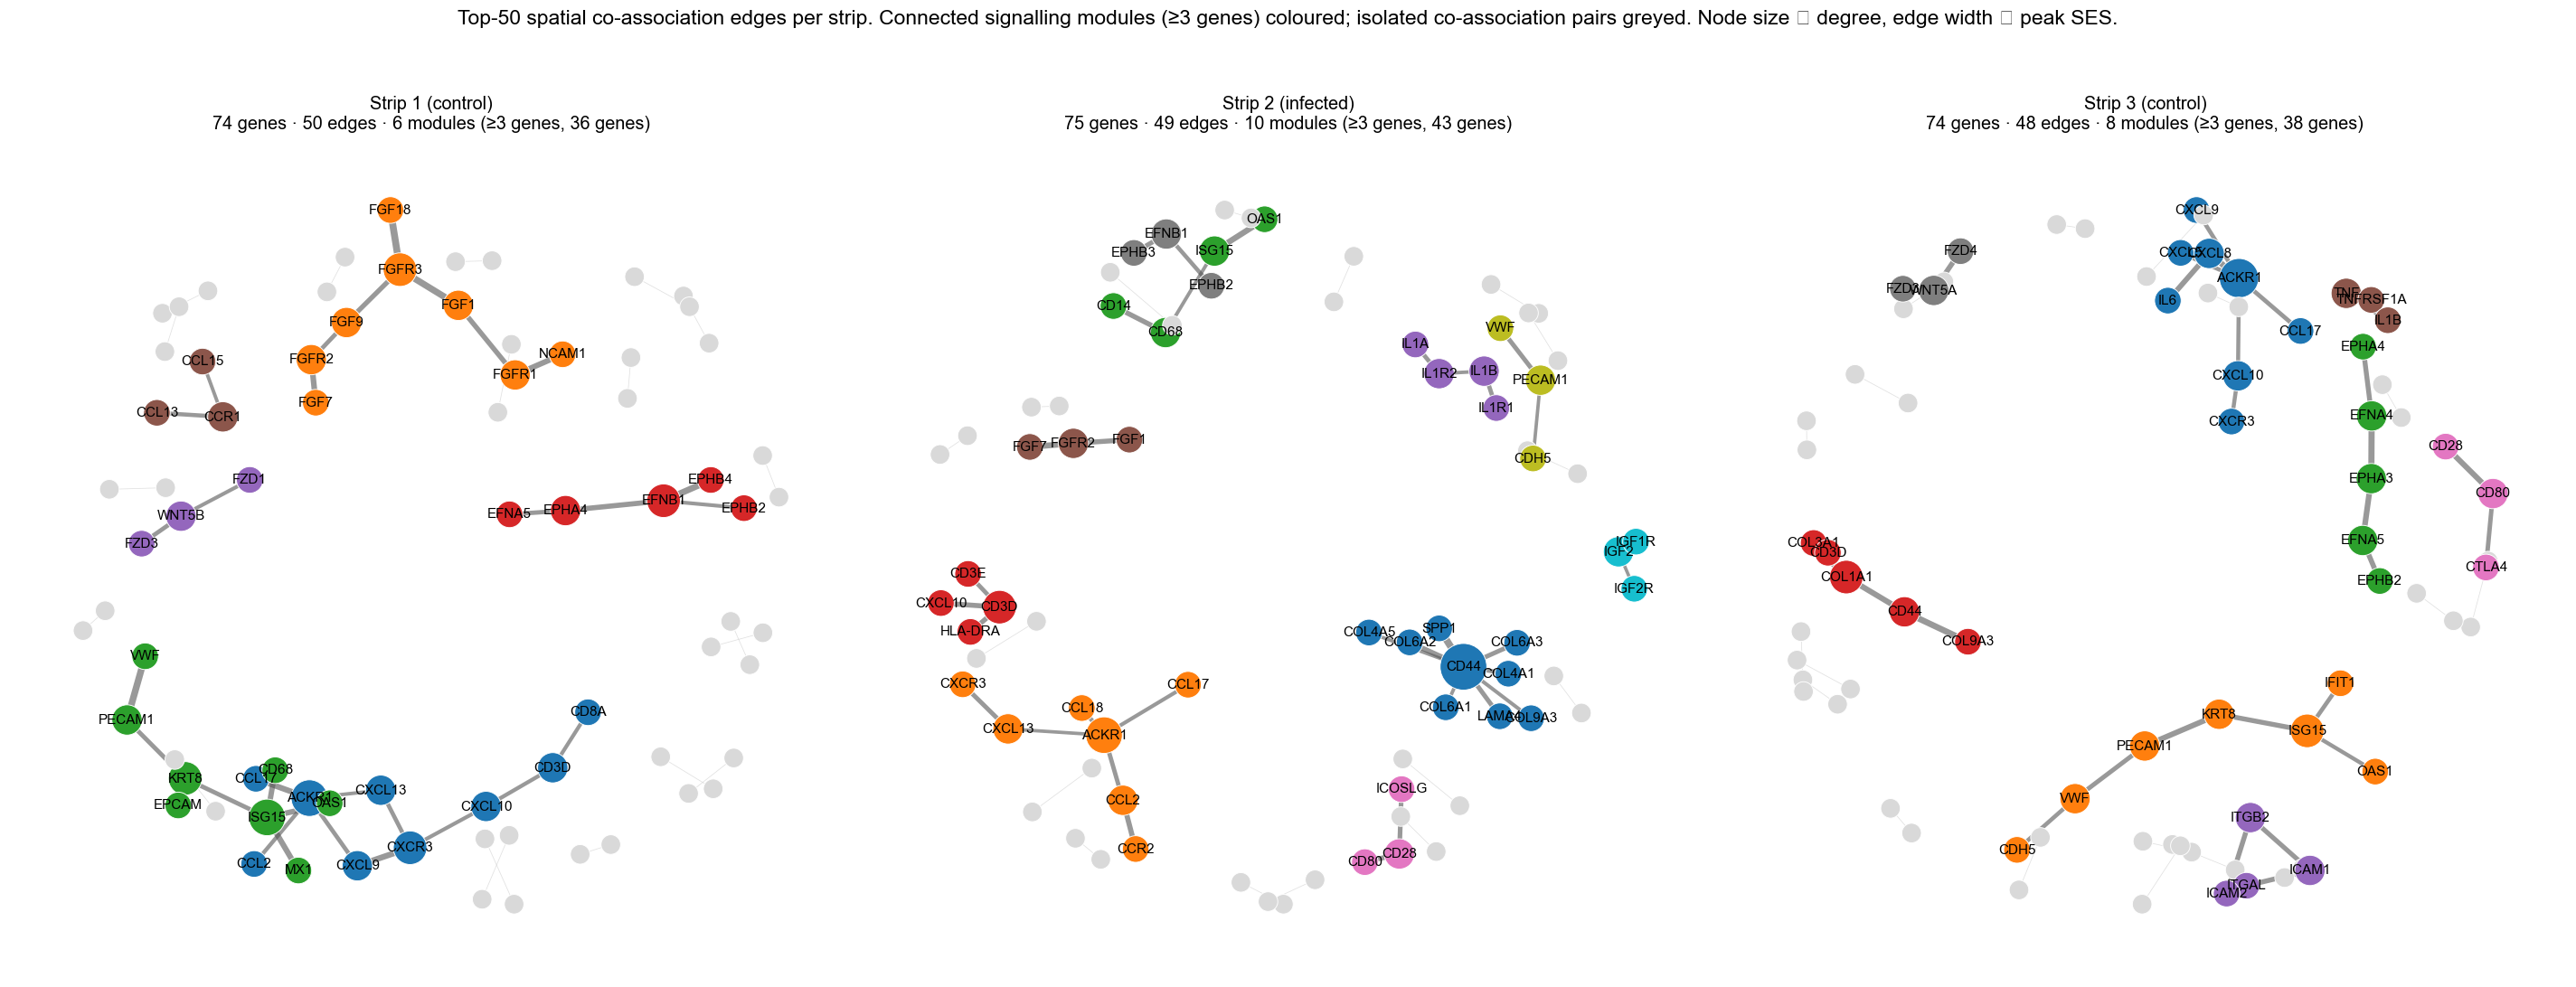

Saved: ..\results\figures\13_G_network.png


In [17]:
# Fig G - Per-strip co-association network with Louvain communities
import networkx as nx

TOP_N_EDGES     = 50   # per strip, ranked by peak SES (positive co-association only)
MODULE_MIN_SIZE = 3    # Louvain communities smaller than this = "isolated pairs"
SEED            = 42

STRIP_TITLE = {"strip_1": "Strip 1 (control)",
               "strip_2": "Strip 2 (infected)",
               "strip_3": "Strip 3 (control)"}

fig, axes = plt.subplots(1, 3, figsize=(26, 9.5))
module_cmap = plt.get_cmap("tab10")

for ax, strip in zip(axes, ["strip_1", "strip_2", "strip_3"]):
    sub = df[(df["strip"] == strip) & (df["peak_ses"] > 0)]
    sub = sub.sort_values("peak_ses", ascending=False).head(TOP_N_EDGES)

    G = nx.Graph()
    for _, row in sub.iterrows():
        w = float(row["peak_ses"])                      # keep stronger edge if a pair recurs (v1 & v2)
        if G.has_edge(row["ligand"], row["receptor"]) and \
           w <= G[row["ligand"]][row["receptor"]]["weight"]:
            continue
        G.add_edge(row["ligand"], row["receptor"], weight=w)

    # Louvain communities; colour only genuine modules (>= MODULE_MIN_SIZE genes).
    # The bulk of top-50 edges are disjoint gene-pairs - greying them lets the
    # real connected signalling modules read on the poster.
    communities = sorted(nx.community.louvain_communities(G, weight="weight", seed=SEED),
                         key=len, reverse=True)
    big = [c for c in communities if len(c) >= MODULE_MIN_SIZE]
    node_module = {n: i for i, comp in enumerate(big) for n in comp}

    deg = dict(G.degree())
    node_colours = [module_cmap(node_module[n] % 10) if n in node_module else "#D9D9D9"
                    for n in G.nodes()]
    node_sizes   = [(260 if n in node_module else 90) + 110 * deg[n] for n in G.nodes()]
    wmax = max((d["weight"] for *_, d in G.edges(data=True)), default=1.0)
    edge_widths  = [0.5 + 4.5 * (G[u][v]["weight"] / wmax) if (u in node_module or v in node_module)
                    else 0.5 for u, v in G.edges()]
    edge_colours = ["#555555" if (u in node_module or v in node_module) else "#CCCCCC"
                    for u, v in G.edges()]

    pos = nx.spring_layout(G, weight="weight", seed=SEED, k=0.85, iterations=200)
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, edge_color=edge_colours, alpha=0.6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_colours,
                           linewidths=0.6, edgecolors="white")
    labels = {n: n for n in G.nodes() if n in node_module or deg[n] >= 2}
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=10, font_weight="medium")

    ax.set_title(f"{STRIP_TITLE[strip]}\n{G.number_of_nodes()} genes · "
                 f"{G.number_of_edges()} edges · {len(big)} modules "
                 f"(≥{MODULE_MIN_SIZE} genes, {sum(len(c) for c in big)} genes)",
                 fontsize=13)
    ax.set_axis_off()

fig.suptitle("Top-50 spatial co-association edges per strip. Connected signalling modules "
             "(≥3 genes) coloured; isolated co-association pairs greyed. "
             "Node size ∝ degree, edge width ∝ peak SES.", fontsize=15, y=1.04)
plt.tight_layout()

out = REPO / "results" / "figures" / "13_G_network.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## 9. Fig H: UMAP of L(r) profile vectors

Each (pair, strip) row carries a 50-point observed `L(r)` curve. Treating that curve as a feature vector and projecting to 2-D with UMAP asks: **do pairs with similar spatial-association *curve shapes* cluster together, and does that recover biological grouping?** Columns are standardised first so the embedding reflects curve shape rather than absolute `L` magnitude (which scales with transcript abundance). Coloured by pre-registered group. Poster panel.

C:\Users\Harry\Desktop\NoSegs_Project\cosmx-pointpattern\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


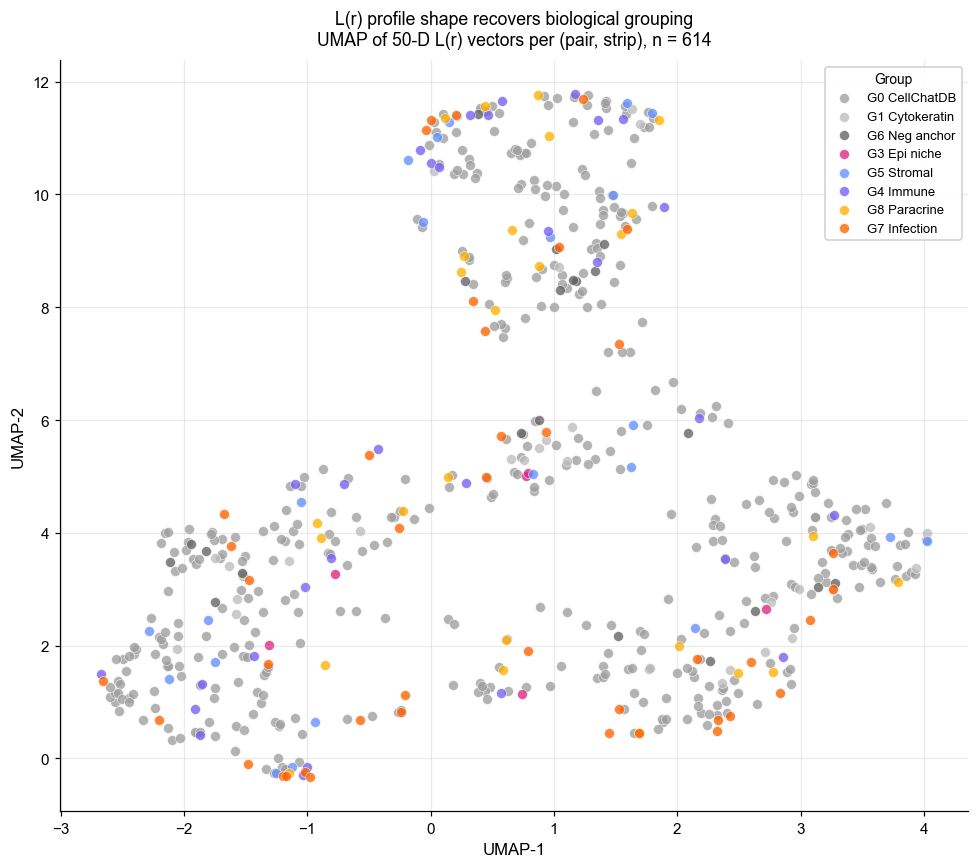

Saved: ..\results\figures\13_H_umap.png


In [18]:
# Fig H - UMAP of 50-D L(r) profile vectors, coloured by group
from sklearn.preprocessing import StandardScaler
import umap

# Each (pair, strip) row's observed L(r) is a 50-D curve. Standardise per radius
# (column) so the embedding is driven by curve *shape*, not absolute L magnitude
# (which scales with transcript abundance / tissue density).
X  = np.vstack([np.asarray(v, float) for v in df["l_obs"]])
Xs = StandardScaler().fit_transform(X)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean",
                    random_state=42)
emb = reducer.fit_transform(Xs)
df["umap_x"], df["umap_y"] = emb[:, 0], emb[:, 1]

fig, ax = plt.subplots(figsize=(9, 8))
# Draw diffuse groups first (behind), focal/biological groups on top.
z_order = ["G0_cellchatdb", "G1_cytokeratin", "G6_negative_anchor",
           "G3_epi_niche", "G5_stromal", "G4_immune_celltype",
           "G8_paracrine", "G7_infection"]
for g in z_order:
    sub = df[df["group"] == g]
    if len(sub) == 0:
        continue
    ax.scatter(sub["umap_x"], sub["umap_y"], s=42, alpha=0.78,
               color=palette[g], label=nice_labels[g].replace("\n", " "),
               edgecolors="white", linewidths=0.4)

ax.set_xlabel("UMAP-1", fontsize=11)
ax.set_ylabel("UMAP-2", fontsize=11)
ax.set_title("L(r) profile shape recovers biological grouping\n"
             f"UMAP of 50-D L(r) vectors per (pair, strip), n = {len(df)}",
             fontsize=11.5, pad=10)
ax.legend(title="Group", fontsize=8.5, title_fontsize=9, loc="best",
          framealpha=0.92)
ax.grid(alpha=0.25)
sns.despine()
plt.tight_layout()

out = REPO / "results" / "figures" / "13_H_umap.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")